<a href="https://colab.research.google.com/github/ShachiPradhan/ames-housing/blob/main/ameshousing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving AmesHousing.csv to AmesHousing.csv


In [5]:
import os
os.makedirs('data', exist_ok=True)
os.rename('AmesHousing.csv', 'data/AmesHousing.csv')

In [16]:
# ============================================================
# CELL 1: Setup — download data, import libraries
# ============================================================
!mkdir -p data
!wget -q -O data/AmesHousing.csv https://raw.githubusercontent.com/learn-co-curriculum/dsc-pandas-eda-lab/master/data/ames.csv

# NOTE: If you already uploaded your own AmesHousing.csv into data/,
# comment out the two lines above and keep your file.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

print("Setup complete ✅")


Setup complete ✅


In [17]:
# ============================================================
# CELL 2: Load the dataset
# ============================================================

# Option A: load the raw AmesHousing.csv you downloaded
df = pd.read_csv('data/AmesHousing.csv')

# If your file has an 'Order' column, drop it
if 'Order' in df.columns:
    df = df.drop(columns=['Order'])

# If your file has a 'PID' column, set it as index
if 'PID' in df.columns:
    df = df.set_index('PID')

# Standardize column names (remove spaces + fix casing)
# This is important because the raw AmesHousing.csv uses spaces
df.columns = (df.columns
                .str.replace(' ', '', regex=False))

# Show info
print("Shape:", df.shape)
print("\nColumns (first 10):")
print(df.columns[:10].tolist())
df.head()

Shape: (1460, 81)

Columns (first 10):
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities']


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [18]:
# ============================================================
# CELL 3: Sanity check
# ============================================================
print("Shape:", df.shape)
print("Total nulls:", df.isnull().sum().sum())
print("Numeric columns:", df.select_dtypes(include='number').shape[1])
print("Object columns:", df.select_dtypes(include='object').shape[1])

print("\nColumn data types:")
print(df.dtypes.value_counts())

print("\nUnique values in a few key columns:")
for c in ['SalePrice', 'TotRmsAbvGrd', 'OverallCond', 'YrSold', 'YearBuilt']:
    if c in df.columns:
        print(f"  {c}: min={df[c].min()}, max={df[c].max()}, dtype={df[c].dtype}")

Shape: (1460, 81)
Total nulls: 7829
Numeric columns: 38
Object columns: 43

Column data types:
object     43
int64      35
float64     3
Name: count, dtype: int64

Unique values in a few key columns:
  SalePrice: min=34900, max=755000, dtype=int64
  TotRmsAbvGrd: min=2, max=14, dtype=int64
  OverallCond: min=1, max=9, dtype=int64
  YrSold: min=2006, max=2010, dtype=int64
  YearBuilt: min=1872, max=2010, dtype=int64


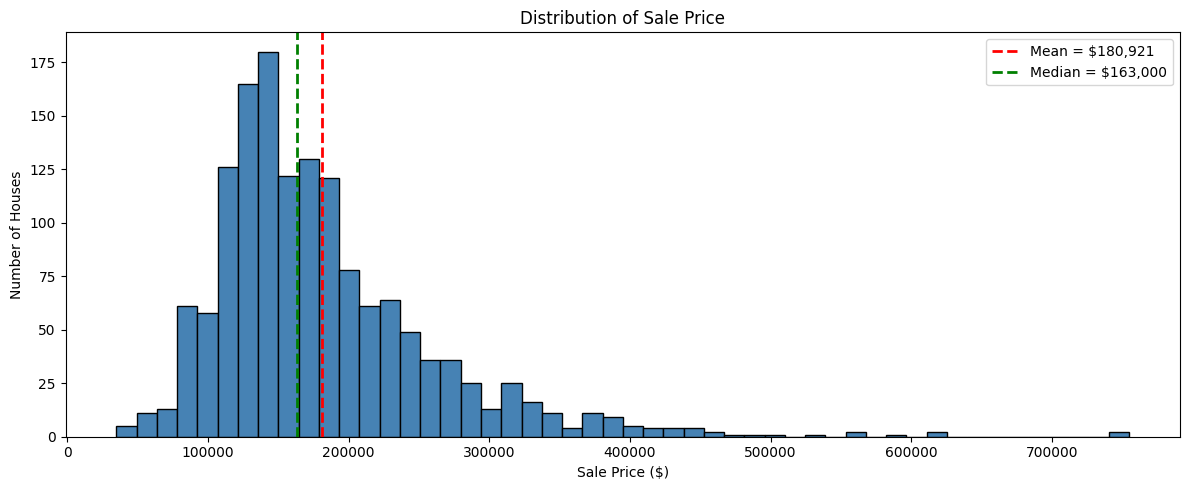

Mean:    180921.2
Median:  163000.0
Std:     79442.5
Skew:    1.883


In [19]:
# ============================================================
# CELL 4: SalePrice — histogram + stats
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
ax.axvline(df['SalePrice'].mean(), color='red', linestyle='--',
           linewidth=2, label=f"Mean = ${df['SalePrice'].mean():,.0f}")
ax.axvline(df['SalePrice'].median(), color='green', linestyle='--',
           linewidth=2, label=f"Median = ${df['SalePrice'].median():,.0f}")
ax.set_title('Distribution of Sale Price')
ax.set_xlabel('Sale Price ($)')
ax.set_ylabel('Number of Houses')
ax.legend()
plt.tight_layout()
plt.show()

print("Mean:   ", round(df['SalePrice'].mean(), 2))
print("Median: ", round(df['SalePrice'].median(), 2))
print("Std:    ", round(df['SalePrice'].std(), 2))
print("Skew:   ", round(df['SalePrice'].skew(), 3))

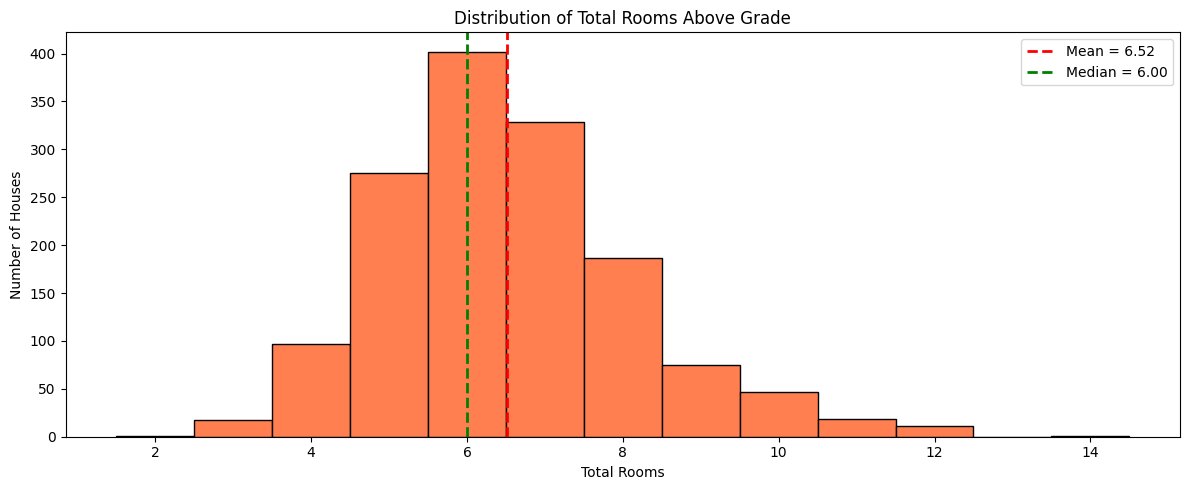

Mean:    6.52
Median:  6.0
Std:     1.63


In [20]:
# ============================================================
# CELL 5: TotRmsAbvGrd — histogram + stats
# ============================================================
col = 'TotRmsAbvGrd'

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df[col],
        bins=range(int(df[col].min()), int(df[col].max()) + 2),
        color='coral', edgecolor='black', align='left')
ax.axvline(df[col].mean(), color='red', linestyle='--',
           linewidth=2, label=f"Mean = {df[col].mean():.2f}")
ax.axvline(df[col].median(), color='green', linestyle='--',
           linewidth=2, label=f"Median = {df[col].median():.2f}")
ax.set_title('Distribution of Total Rooms Above Grade')
ax.set_xlabel('Total Rooms')
ax.set_ylabel('Number of Houses')
ax.legend()
plt.tight_layout()
plt.show()

print("Mean:   ", round(df[col].mean(), 2))
print("Median: ", round(df[col].median(), 2))
print("Std:    ", round(df[col].std(), 2))

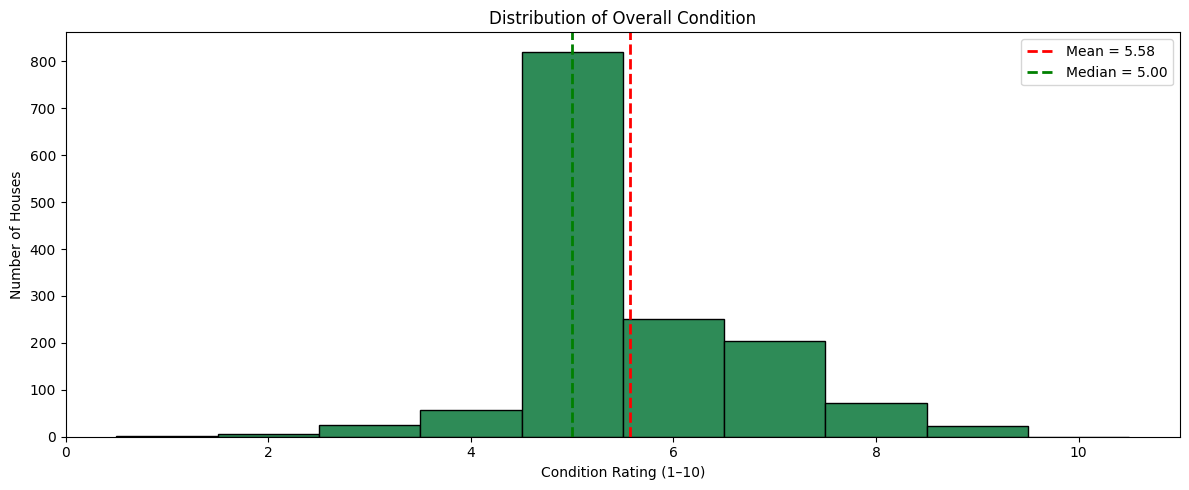

Mean:    5.58
Median:  5.0
Std:     1.11

Value counts (sorted):
OverallCond
1      1
2      5
3     25
4     57
5    821
6    252
7    205
8     72
9     22
Name: count, dtype: int64


In [21]:
# ============================================================
# CELL 6: OverallCond — histogram + stats
# ============================================================
col = 'OverallCond'

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df[col], bins=range(1, 12), color='seagreen',
        edgecolor='black', align='left')
ax.axvline(df[col].mean(), color='red', linestyle='--',
           linewidth=2, label=f"Mean = {df[col].mean():.2f}")
ax.axvline(df[col].median(), color='green', linestyle='--',
           linewidth=2, label=f"Median = {df[col].median():.2f}")
ax.set_title('Distribution of Overall Condition')
ax.set_xlabel('Condition Rating (1–10)')
ax.set_ylabel('Number of Houses')
ax.legend()
plt.tight_layout()
plt.show()

print("Mean:   ", round(df[col].mean(), 2))
print("Median: ", round(df[col].median(), 2))
print("Std:    ", round(df[col].std(), 2))
print("\nValue counts (sorted):")
print(df[col].value_counts().sort_index())

Below average: 88 rows
Average:       821 rows
Above average: 551 rows


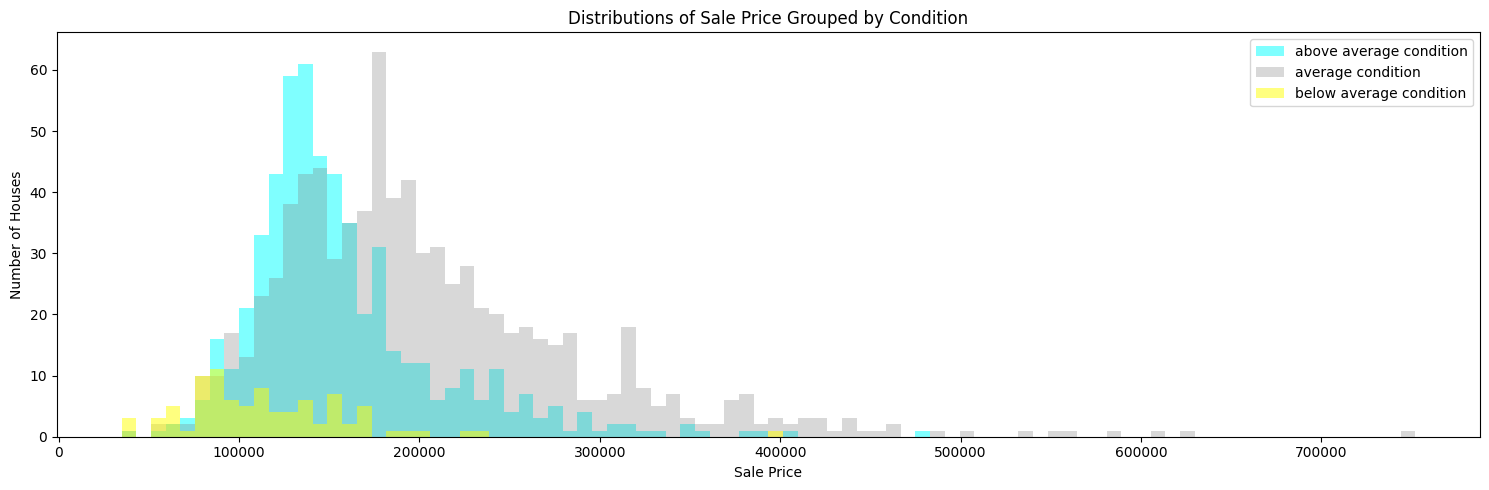

In [22]:
# ============================================================
# CELL 7: Subsets based on OverallCond
# ============================================================
below_average_condition = df[df['OverallCond'] < 5]
average_condition       = df[df['OverallCond'] == 5]
above_average_condition = df[df['OverallCond'] > 5]

print("Below average:", below_average_condition.shape[0], "rows")
print("Average:      ", average_condition.shape[0], "rows")
print("Above average:", above_average_condition.shape[0], "rows")

# Set up plot
fig, ax = plt.subplots(figsize=(15, 5))

# Custom bins so all histograms share the same scale
bins = range(int(df['SalePrice'].min()),
             int(df['SalePrice'].max()),
             int(df['SalePrice'].median()) // 20)

# Three overlapping histograms with transparency
ax.hist(above_average_condition['SalePrice'],
        label='above average condition', bins=bins, color='cyan', alpha=0.5)
ax.hist(average_condition['SalePrice'],
        label='average condition', bins=bins, color='gray', alpha=0.3)
ax.hist(below_average_condition['SalePrice'],
        label='below average condition', bins=bins, color='yellow', alpha=0.5)

ax.set_title('Distributions of Sale Price Grouped by Condition')
ax.set_xlabel('Sale Price')
ax.set_ylabel('Number of Houses')
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# CELL 8: Correlations with SalePrice
# ============================================================
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

# Most positive (skip SalePrice itself, which is at index 0)
most_pos_col = corr.index[1]
most_pos_val = corr.iloc[1]

# Most negative
most_neg_col = corr.index[-1]
most_neg_val = corr.iloc[-1]

print(f"Most positively correlated: {most_pos_col} ({most_pos_val:.3f})")
print(f"Most negatively correlated: {most_neg_col} ({most_neg_val:.3f})")

print("\nTop 10 correlations with SalePrice:")
print(corr.head(11).round(3))

Most positively correlated: OverallQual (0.791)
Most negatively correlated: KitchenAbvGr (-0.136)

Top 10 correlations with SalePrice:
SalePrice       1.000
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
Name: SalePrice, dtype: float64


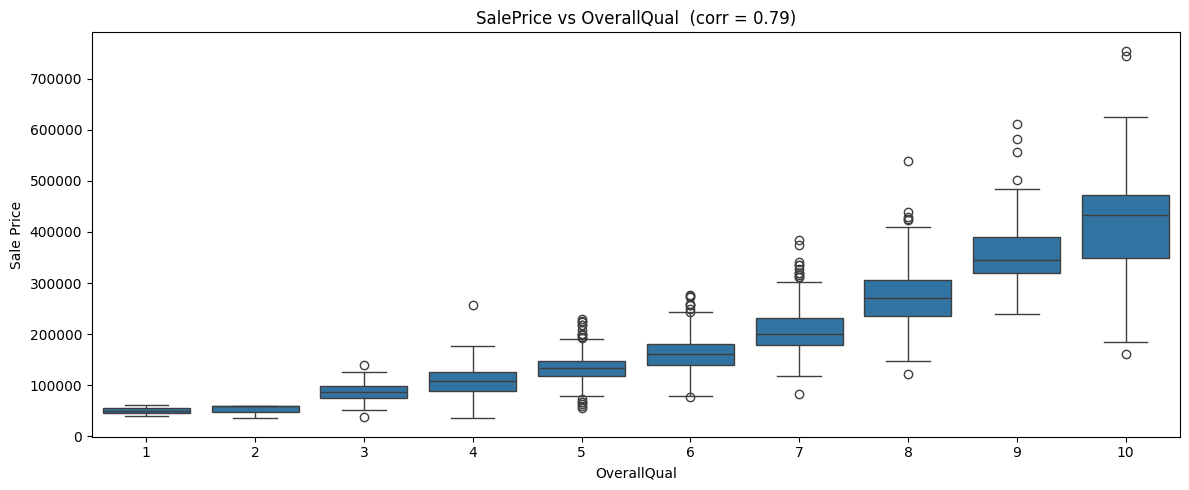

In [24]:
# ============================================================
# CELL 9: Box plot — most positively correlated feature
# ============================================================
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(x=df[most_pos_col], y=df['SalePrice'], ax=ax)
ax.set_title(f'SalePrice vs {most_pos_col}  (corr = {most_pos_val:.2f})')
ax.set_xlabel(most_pos_col)
ax.set_ylabel('Sale Price')
plt.tight_layout()
plt.show()

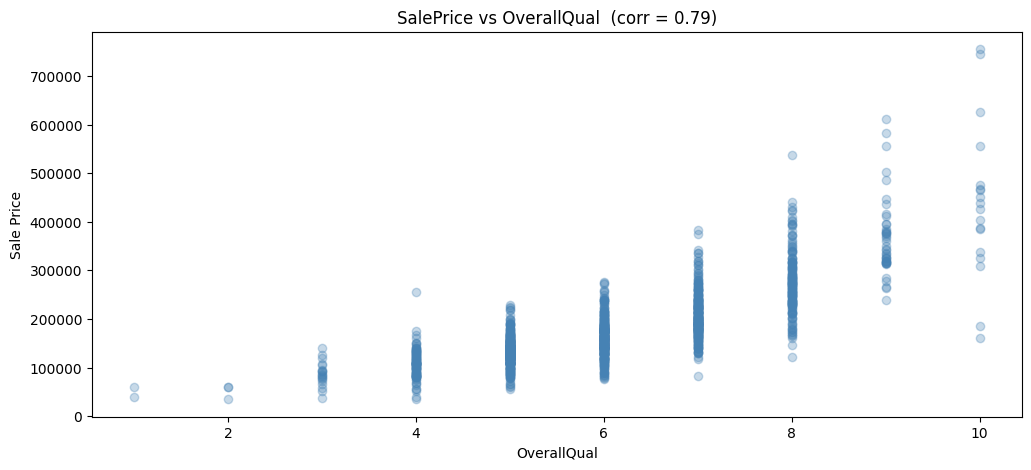

In [25]:
# Fallback scatterplot (only run if boxplot looks cluttered)
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(df[most_pos_col], df['SalePrice'], alpha=0.3, color='steelblue')
ax.set_title(f'SalePrice vs {most_pos_col}  (corr = {most_pos_val:.2f})')
ax.set_xlabel(most_pos_col)
ax.set_ylabel('Sale Price')
plt.show()

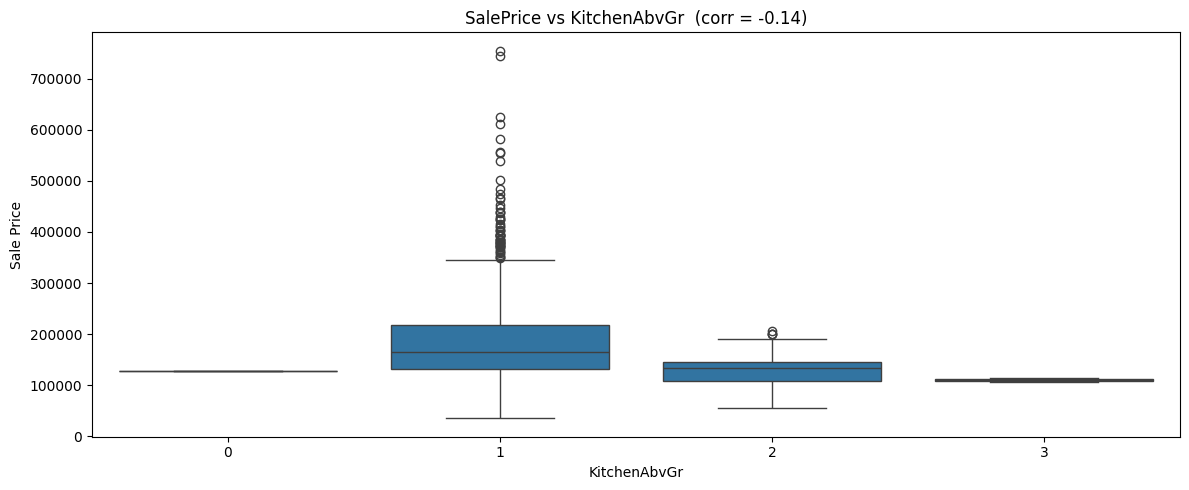

In [26]:
# ============================================================
# CELL 10: Box plot — most negatively correlated feature
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(x=df[most_neg_col], y=df['SalePrice'], ax=ax)
ax.set_title(f'SalePrice vs {most_neg_col}  (corr = {most_neg_val:.2f})')
ax.set_xlabel(most_neg_col)
ax.set_ylabel('Sale Price')
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# CELL 11: Look at year-sold distribution
# ============================================================
df['YrSold'].value_counts().sort_index()

,count
YrSold,
2006,314
2007,329
2008,304
2009,338
2010,175


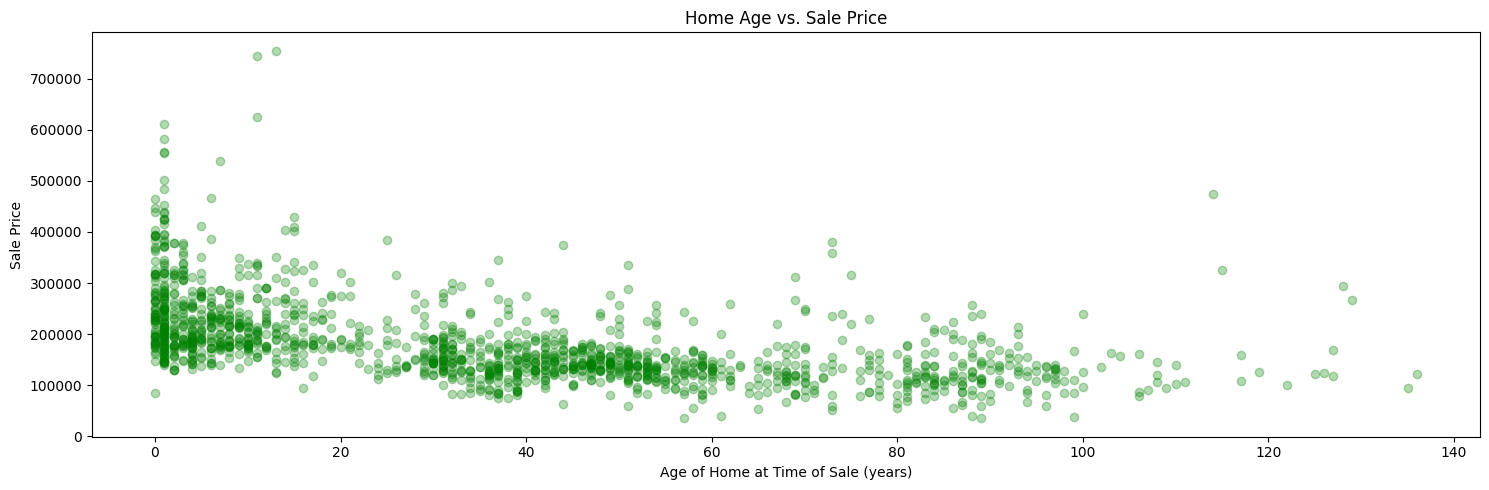

Correlation Age vs SalePrice: -0.523


In [28]:
# ============================================================
# CELL 12: Engineer 'Age' and plot vs SalePrice
# ============================================================
df['Age'] = df['YrSold'] - df['YearBuilt']

fig, ax = plt.subplots(figsize=(15, 5))
ax.scatter(df['Age'], df['SalePrice'], alpha=0.3, color='green')
ax.set_title('Home Age vs. Sale Price')
ax.set_xlabel('Age of Home at Time of Sale (years)')
ax.set_ylabel('Sale Price')
plt.tight_layout()
plt.show()

print("Correlation Age vs SalePrice:", round(df['Age'].corr(df['SalePrice']), 3))

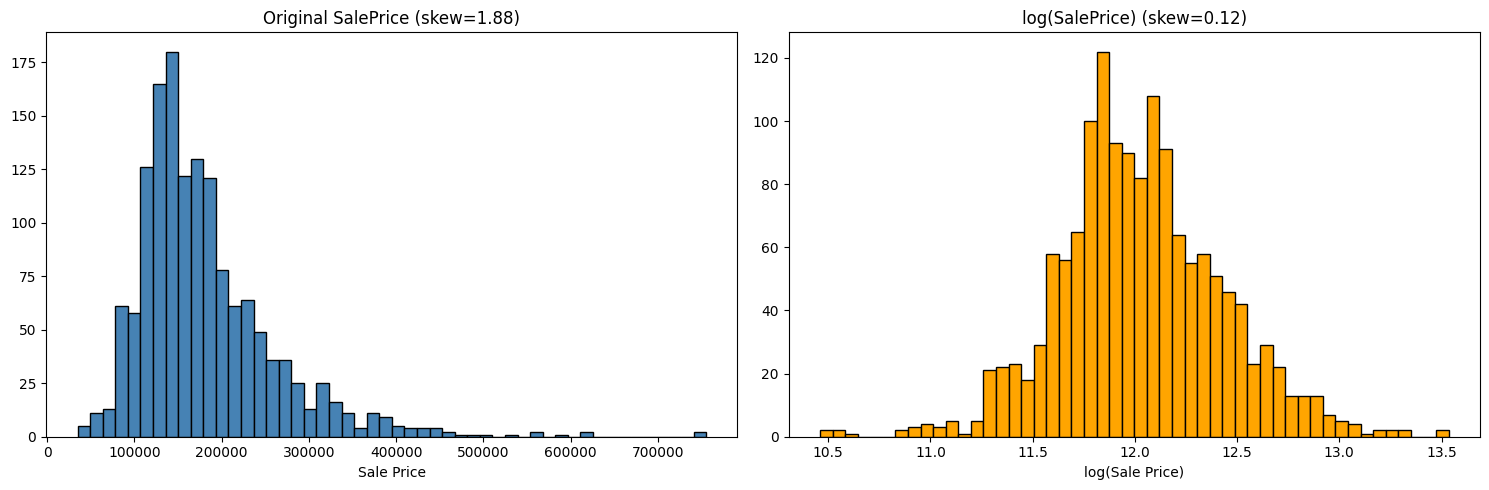

In [29]:
# ============================================================
# CELL 13 (Bonus): Log-transform SalePrice to reduce skew
# ============================================================
df['LogSalePrice'] = np.log(df['SalePrice'])

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 5))

ax1.hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
ax1.set_title(f"Original SalePrice (skew={df['SalePrice'].skew():.2f})")
ax1.set_xlabel('Sale Price')

ax2.hist(df['LogSalePrice'], bins=50, color='orange', edgecolor='black')
ax2.set_title(f"log(SalePrice) (skew={df['LogSalePrice'].skew():.2f})")
ax2.set_xlabel('log(Sale Price)')

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# CELL 14: Summary snapshot
# ============================================================
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Nulls: {df.isnull().sum().sum()}")
print()
print("SalePrice stats:")
print(f"  Mean:   ${df['SalePrice'].mean():,.0f}")
print(f"  Median: ${df['SalePrice'].median():,.0f}")
print(f"  Std:    ${df['SalePrice'].std():,.0f}")
print(f"  Skew:   {df['SalePrice'].skew():.2f}")
print()
print(f"Top predictor: {most_pos_col} (corr={most_pos_val:.2f})")
print(f"Age vs SalePrice corr: {df['Age'].corr(df['SalePrice']):.2f}")
print("=" * 50)

DATASET SUMMARY
Rows: 1460
Columns: 83
Nulls: 7829

SalePrice stats:
  Mean:   $180,921
  Median: $163,000
  Std:    $79,443
  Skew:   1.88

Top predictor: OverallQual (corr=0.79)
Age vs SalePrice corr: -0.52
